# Merge and Export Machine Learning Dataset (regression) — Zaragoza
This notebook gathers all pre-calculated features (OSM POIs, Land Use, Momepy) and merges them with the **real noise values in dB** into one comprehensive `.csv` table for testing the Barcelona regression models, mirroring `notebooks/_elena/01_create_dataset_regre.ipynb`.

## Note: Data Requirements

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt

print("Libraries imported.")

Libraries imported.


## Load the datasets

In [2]:
path_osm_roads    = "data/osm_roads_noise_regre.csv"
path_momepy_roads = "data/momepy_roads_features.csv"
path_osm_points   = "data/osm_points_features.csv"
path_osmlanduse   = "data/osm_landuse_features.csv"

df_osm_roads    = pd.read_csv(path_osm_roads)
df_momepy_roads = pd.read_csv(path_momepy_roads)
df_osm_points   = pd.read_csv(path_osm_points)
df_osm_landuse  = pd.read_csv(path_osmlanduse)

print("Data loaded successfully.")

Data loaded successfully.


In [3]:
df_osm_roads.head()

,road_id,noise_day,noise_evening,noise_night,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street
0,30389382_249502424_0,65.0,65.0,55.0,5,1098.130859,0.000000,148.733726,294.245365,0.000000,80.489500
1,30389382_30389461_0,75.0,70.0,60.0,2,1098.130859,0.000000,148.733726,328.711712,0.000000,0.000000
2,30389389_4398109455_0,75.0,70.0,60.0,3,733.149952,191.894385,0.000000,21.763470,0.000000,454.411270
3,30389391_30575132_0,75.0,75.0,65.0,2,764.280886,0.000000,0.000000,403.268057,89.429710,407.502393
4,30389400_3847861549_0,75.0,70.0,65.0,2,1318.929427,0.000000,66.397843,75.094780,28.661399,154.125944


In [4]:
df_momepy_roads.head()

,road_id,width,openness,betweenness,closeness_global,closeness_400,straightness
0,30389382_249502424_0,14.944760,0.375000,0.000679,0.000191,0.000022,0.828224
1,30389382_30389461_0,32.776400,0.625000,0.014229,0.000192,0.000023,0.830235
2,30389389_4398109455_0,37.421218,0.500000,0.001715,0.000183,0.000011,0.813448
3,30389391_30575132_0,50.000000,1.000000,0.027712,0.000187,0.000016,0.839237
4,30389400_3847861549_0,40.184419,0.666667,0.011389,0.000193,0.000020,0.838237


In [5]:
# Drop non-ML columns from momepy (openness is a morphological intermediate)
df_momepy_roads.drop(['openness'], axis=1, inplace=True)
df_momepy_roads.head()

,road_id,width,betweenness,closeness_global,closeness_400,straightness
0,30389382_249502424_0,14.944760,0.000679,0.000191,0.000022,0.828224
1,30389382_30389461_0,32.776400,0.014229,0.000192,0.000023,0.830235
2,30389389_4398109455_0,37.421218,0.001715,0.000183,0.000011,0.813448
3,30389391_30575132_0,50.000000,0.027712,0.000187,0.000016,0.839237
4,30389400_3847861549_0,40.184419,0.011389,0.000193,0.000020,0.838237


In [6]:
df_osm_points.head()

,road_id,signals,transport,pois
0,30389382_249502424_0,0.062375,0.000000,0.097381
1,30389382_30389461_0,0.062375,0.024000,0.120001
2,30389389_4398109455_0,0.031287,0.010429,0.015644
3,30389391_30575132_0,0.062375,0.000000,0.091570
4,30389400_3847861549_0,0.000000,0.026187,0.026569


In [7]:
df_osm_landuse.head()

,road_id,green,industrial,commercial
0,30389382_249502424_0,4.203108,0.0,0.0
1,30389382_30389461_0,23.587984,0.0,0.0
2,30389389_4398109455_0,3.180723,0.0,0.0
3,30389391_30575132_0,26.085707,0.0,0.0
4,30389400_3847861549_0,19.616961,0.0,0.0


## Merge dataframes

In [8]:
def merge_feature_dataframe(base_df, feature_df, cols_to_drop):
    clean_df = feature_df.drop(columns=[c for c in cols_to_drop if c in feature_df.columns], errors='ignore')
    cols_to_remove = [c for c in clean_df.columns if c in base_df.columns and c != 'road_id']
    clean_df = clean_df.drop(columns=cols_to_remove, errors='ignore')
    if 'road_id' not in clean_df.columns or 'road_id' not in base_df.columns:
        return base_df
    clean_df['road_id'] = clean_df['road_id'].astype(str)
    base_df = base_df.copy()
    base_df['road_id'] = base_df['road_id'].astype(str)
    return base_df.merge(clean_df, on='road_id', how='left')

In [9]:
ml_dataset = df_osm_roads.copy()
cols_to_drop = ['noise_day', 'noise_evening', 'noise_night']

print("Road ID types:")
print(f"ml_dataset: {ml_dataset['road_id'].dtype}")

for name, df in [
    ('OSM Points',   df_osm_points),
    ('Momepy Roads', df_momepy_roads),
    ('OSM Landuse',  df_osm_landuse),
]:
    if 'road_id' in df.columns:
        print(f"{name}: {df['road_id'].dtype}")
    else:
        print(f"{name}: NO road_id column!")
    ml_dataset = merge_feature_dataframe(ml_dataset, df, cols_to_drop)

ml_dataset = ml_dataset.fillna(0)

display(ml_dataset.head(10))
ml_dataset.info()
print(f"Final dataset shape: {ml_dataset.shape}")

Road ID types:
ml_dataset: str
OSM Points: str
Momepy Roads: str
OSM Landuse: str


,road_id,noise_day,noise_evening,noise_night,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,...,transport,pois,width,betweenness,closeness_global,closeness_400,straightness,green,industrial,commercial
0,30389382_249502424_0,65.0,65.0,55.0,5,1098.130859,0.000000,148.733726,294.245365,0.000000,...,0.000000,0.097381,14.944760,0.000679,0.000191,0.000022,0.828224,4.203108,0.0,0.0
1,30389382_30389461_0,75.0,70.0,60.0,2,1098.130859,0.000000,148.733726,328.711712,0.000000,...,0.024000,0.120001,32.776400,0.014229,0.000192,0.000023,0.830235,23.587984,0.0,0.0
2,30389389_4398109455_0,75.0,70.0,60.0,3,733.149952,191.894385,0.000000,21.763470,0.000000,...,0.010429,0.015644,37.421218,0.001715,0.000183,0.000011,0.813448,3.180723,0.0,0.0
3,30389391_30575132_0,75.0,75.0,65.0,2,764.280886,0.000000,0.000000,403.268057,89.429710,...,0.000000,0.091570,50.000000,0.027712,0.000187,0.000016,0.839237,26.085707,0.0,0.0
4,30389400_3847861549_0,75.0,70.0,65.0,2,1318.929427,0.000000,66.397843,75.094780,28.661399,...,0.026187,0.026569,40.184419,0.011389,0.000193,0.000020,0.838237,19.616961,0.0,0.0
5,30389400_30389426_0,75.0,70.0,60.0,2,1325.568571,0.000000,66.397843,75.005472,28.661399,...,0.026187,0.035710,46.760827,0.076644,0.000193,0.000022,0.842614,19.814660,0.0,0.0
6,30389401_3725362792_0,70.0,70.0,60.0,3,745.489180,124.091728,0.000000,255.231129,63.738481,...,0.026187,0.000000,45.489842,0.000387,0.000185,0.000012,0.822373,5.911934,0.0,0.0
7,30389406_263710328_0,70.0,70.0,60.0,4,1766.001943,81.312298,92.404044,0.000000,0.000000,...,0.000000,0.035392,50.000000,0.021573,0.000200,0.000028,0.834564,50.437858,0.0,0.0
8,30389406_158680076_0,70.0,70.0,60.0,5,1762.183659,81.311700,82.962120,0.000000,0.000000,...,0.000000,0.084603,50.000000,0.001271,0.000200,0.000029,0.836043,31.323492,0.0,0.0
9,30389407_30575306_0,75.0,75.0,65.0,2,730.308930,0.000000,0.000000,222.991401,70.064173,...,0.000000,0.047854,50.000000,0.053008,0.000187,0.000022,0.832609,1.284292,0.0,0.0


<class 'pandas.DataFrame'>
RangeIndex: 14600 entries, 0 to 14599
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   road_id                14600 non-null  str    
 1   noise_day              14600 non-null  float64
 2   noise_evening          14600 non-null  float64
 3   noise_night            14600 non-null  float64
 4   road_category          14600 non-null  int64  
 5   dist_to_trunk          14600 non-null  float64
 6   dist_to_primary        14600 non-null  float64
 7   dist_to_secondary      14600 non-null  float64
 8   dist_to_tertiary       14600 non-null  float64
 9   dist_to_residential    14600 non-null  float64
 10  dist_to_living_street  14600 non-null  float64
 11  signals                14600 non-null  float64
 12  transport              14600 non-null  float64
 13  pois                   14600 non-null  float64
 14  width                  14600 non-null  float64
 15  betweenness  

## Noise distribution

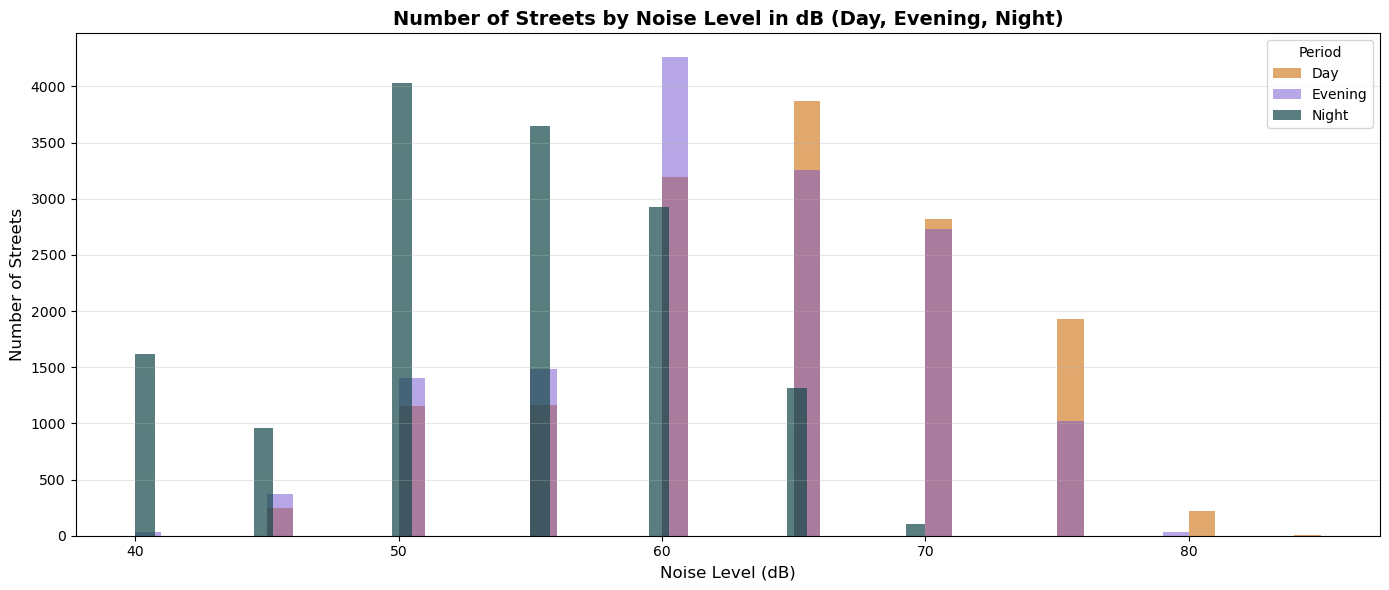

In [10]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.hist(ml_dataset['noise_day'], bins=40, color='#d58430', alpha=0.7, label='Day')
ax.hist(ml_dataset['noise_evening'], bins=40, color='#7251ce', alpha=0.5, label='Evening')
ax.hist(ml_dataset['noise_night'], bins=40, color='#144849', alpha=0.7, label='Night')
ax.set_title('Number of Streets by Noise Level in dB (Day, Evening, Night)', fontsize=14, fontweight='bold')
ax.set_xlabel('Noise Level (dB)', fontsize=12)
ax.set_ylabel('Number of Streets', fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Period')
plt.tight_layout()
plt.show()

## Export to CSV
Final master table for testing the Barcelona regression models.

In [11]:
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)

final_path = os.path.join(output_dir, "zgz_noise_regre_ml_dataset.csv")
ml_dataset.to_csv(final_path, index=False)

print(f"Dataset successfully exported to: {final_path}")

Dataset successfully exported to: data\zgz_noise_regre_ml_dataset.csv


## Subsample
Stratified subsample preserving the noise_day distribution. The dB values can be continuous, so the stratification uses 5-dB bins (Barcelona's exact-value stratification would put every street in its own stratum).

In [12]:
sample_size = min(5000, len(ml_dataset))

bins = (ml_dataset['noise_day'] // 5 * 5).astype(int)
proportions = bins.value_counts(normalize=True).sort_index()
samples_per_value = (proportions * sample_size).round().astype(int)

subsampled = pd.concat([
    ml_dataset[bins == val].sample(n=min(n, int((bins == val).sum())), random_state=42, replace=False)
    for val, n in samples_per_value.items() if n > 0
])

subsampled = subsampled.sample(frac=1, random_state=42).reset_index(drop=True)

print((subsampled['noise_day'] // 5 * 5).astype(int).value_counts(normalize=True).sort_index())

noise_day
45    0.0168
50    0.0794
55    0.0798
60    0.2184
65    0.2650
70    0.1928
75    0.1322
80    0.0150
85    0.0006
Name: proportion, dtype: float64


## Before and after sampling

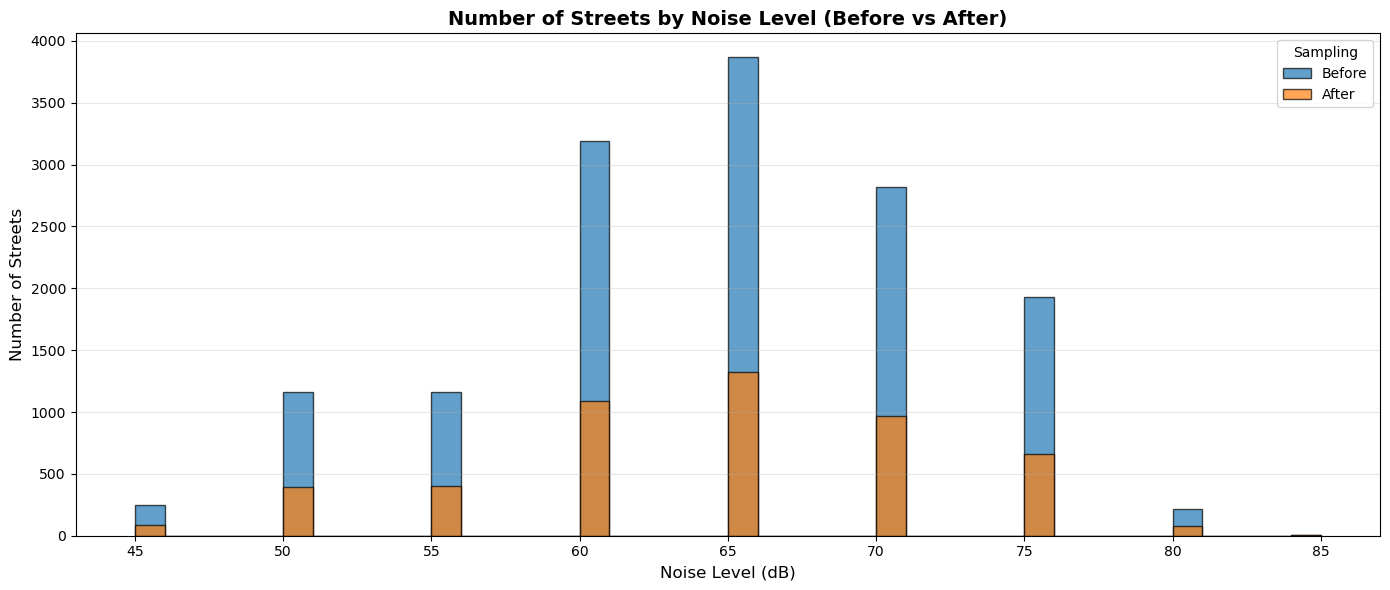

In [13]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.hist(ml_dataset['noise_day'], bins=40, alpha=0.7, label='Before', edgecolor='black')
ax.hist(subsampled['noise_day'], bins=40, alpha=0.7, label='After', edgecolor='black')
ax.set_title('Number of Streets by Noise Level (Before vs After)', fontsize=14, fontweight='bold')
ax.set_xlabel('Noise Level (dB)', fontsize=12)
ax.set_ylabel('Number of Streets', fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Sampling')
plt.tight_layout()
plt.show()

## Export CSV

In [14]:
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)

final_path = os.path.join(output_dir, "zgz_noise_regre_ml_subsample.csv")
subsampled.to_csv(final_path, index=False)

print(f"Dataset successfully exported to: {final_path}")

Dataset successfully exported to: data\zgz_noise_regre_ml_subsample.csv


## Schema check vs Barcelona
The columns must match `bcn_noise_regre_ml_dataset.csv` exactly (names and order) so the pickled scaler/models apply directly.

In [15]:
bcn = pd.read_csv("../../../notebooks/_elena/data/bcn_noise_regre_ml_dataset.csv", nrows=5)

print("Columns match Barcelona schema:", list(ml_dataset.columns) == list(bcn.columns))
print("NaN values:", ml_dataset.isna().sum().sum())
print("Duplicated road_id:", ml_dataset['road_id'].duplicated().sum())
assert list(ml_dataset.columns) == list(bcn.columns), "schema mismatch with Barcelona"
print("Schema parity with Barcelona confirmed.")

Columns match Barcelona schema: True
NaN values: 0
Duplicated road_id: 0
Schema parity with Barcelona confirmed.
